Instalación de librerías necesarias

In [1]:
! pip install pandas scikit-learn seaborn matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable


Configuración e importación de librerías para el modelo

In [2]:
import sys
sys.path.append('../../')

# Importar librerías necesarias
Este notebook replica el flujo de `model_irca.py` para análisis y entrenamiento de un modelo de red neuronal para regresión.

In [3]:
# 1. Importar librerías
from app.database import get_db
from app.services import resultado
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

In [4]:
# 2. Obtener datos de la base de datos
db = next(get_db())
resultados = resultado.get_resultados(db)
df = pd.DataFrame(resultados)

In [5]:
# 3. Análisis de nulos y limpieza de columnas
porcentajes_nulos = df.isnull().mean() * 100
umbral_eliminar = 70  # eliminar columnas con >70% de nulos
columnas_eliminar = porcentajes_nulos[porcentajes_nulos > umbral_eliminar].index.tolist()
df = df.drop(columns=columnas_eliminar)

In [6]:
# 4. Selección y limpieza de columnas numéricas y categóricas
numerical_columns = [col for col in df.columns if 'resultado' in col.lower()]
categorical_columns = [col for col in df.columns if 'diagnostico' in col.lower()]
df.drop(columns=categorical_columns, inplace=True)
df.drop(columns=['IRCA'], inplace=True)
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [7]:
# 5. Imputación de valores nulos en columnas numéricas
imputer_num = SimpleImputer(strategy="median")
df[numerical_columns] = imputer_num.fit_transform(df[numerical_columns])

In [8]:
# 6. División de datos en características y objetivo
X = df.drop(columns=['nivel_Riesgo'], axis=1)
y = df['nivel_Riesgo']

In [9]:
y.unique()

array(['ALTO', 'INVIABLE SANITARIAMENTE', 'SIN RIESGO', 'MEDIO', 'BAJO'],
      dtype=object)

In [10]:
# 7. Normalización de datos
scaler = StandardScaler()
X = scaler.fit_transform(X)

y = pd.factorize(y)[0]  # Convertir categorías a números

y

array([0, 0, 0, ..., 1, 1, 4], shape=(15376,))

In [11]:
# 8. División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 9. Creación y entrenamiento del modelo
model = MLPClassifier(hidden_layer_sizes=(16,), 
                     activation='relu', 
                     solver='adam', 
                     learning_rate='adaptive', 
                     learning_rate_init=0.001,
                     max_iter=1000, 
                     random_state=42, 
                     validation_fraction=0.1, 
                     n_iter_no_change=20, 
                     verbose=True)
history = model.fit(X_train, y_train)

Iteration 1, loss = 1.66364386
Iteration 2, loss = 1.34922365
Iteration 3, loss = 1.12572510
Iteration 4, loss = 0.96441479
Iteration 5, loss = 0.86605363
Iteration 6, loss = 0.80844553
Iteration 7, loss = 0.77117205
Iteration 8, loss = 0.74422652
Iteration 9, loss = 0.72374765
Iteration 10, loss = 0.70748653
Iteration 11, loss = 0.69423386
Iteration 12, loss = 0.68267868
Iteration 13, loss = 0.67250165
Iteration 14, loss = 0.66353481
Iteration 15, loss = 0.65544943
Iteration 16, loss = 0.64769150
Iteration 17, loss = 0.64093756
Iteration 18, loss = 0.63404651
Iteration 19, loss = 0.62768350
Iteration 20, loss = 0.62187356
Iteration 21, loss = 0.61579566
Iteration 22, loss = 0.60987323
Iteration 23, loss = 0.60406414
Iteration 24, loss = 0.59889551
Iteration 25, loss = 0.59441001
Iteration 26, loss = 0.58998940
Iteration 27, loss = 0.58606516
Iteration 28, loss = 0.58226996
Iteration 29, loss = 0.57837351
Iteration 30, loss = 0.57415003
Iteration 31, loss = 0.57085369
Iteration 32, los

/home/juan/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


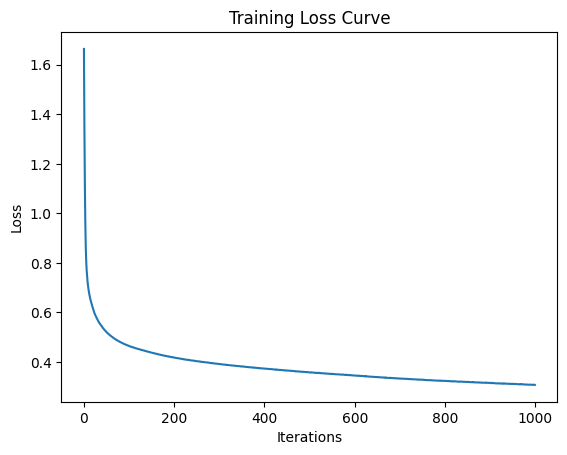

In [13]:
plt.plot(history.loss_curve_)
plt.title('Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

In [14]:
# 10. Evaluación del modelo
y_pred = model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1107   55    9   79    2]
 [  21  454    1    1    0]
 [   0    0  806   12    0]
 [  25    0   87  388    2]
 [   0    0    2    0   25]]


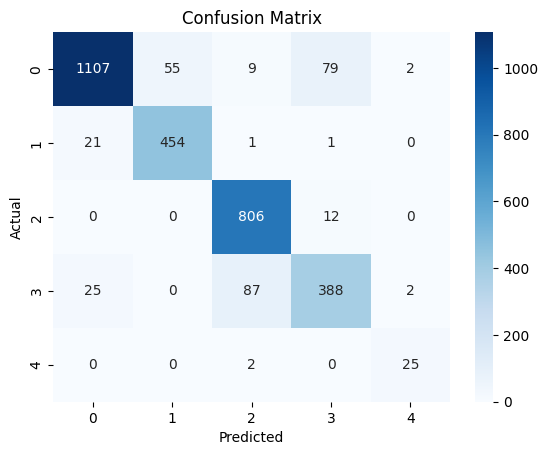

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      1252
           1       0.89      0.95      0.92       477
           2       0.89      0.99      0.94       818
           3       0.81      0.77      0.79       502
           4       0.86      0.93      0.89        27

    accuracy                           0.90      3076
   macro avg       0.88      0.90      0.89      3076
weighted avg       0.91      0.90      0.90      3076



# Interpretación del Reporte de Clasificación

El reporte de clasificación generado por `classification_report` de `sklearn` incluye las siguientes métricas para evaluar el desempeño del modelo de clasificación: **precision**, **recall**, **f1-score** y **support**. A continuación, se explican cada una de estas métricas con ejemplos y fórmulas en formato LaTeX.

---

## 1. **Precision (Precisión)**

La precisión mide qué proporción de las predicciones positivas del modelo son correctas. Es decir, de todas las veces que el modelo predijo una clase positiva, ¿cuántas veces acertó?

**Fórmula:**
$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

**Ejemplo:**
Si el modelo predice que 100 muestras pertenecen a una clase positiva, pero solo 80 de esas predicciones son correctas:
$$
\text{Precision} = \frac{80}{80 + 20} = 0.8 \ (80\%)
$$

**Interpretación:**
Una alta precisión indica que el modelo tiene pocos falsos positivos. Es útil cuando el costo de un falso positivo es alto.

---

## 2. **Recall (Sensibilidad o Exhaustividad)**

El recall mide qué proporción de los casos positivos reales fueron correctamente identificados por el modelo. Es decir, de todas las muestras que realmente pertenecen a una clase positiva, ¿cuántas fueron detectadas?

**Fórmula:**
$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

**Ejemplo:**
Si hay 100 muestras que realmente pertenecen a una clase positiva, y el modelo identifica correctamente 80 de ellas:
$$
\text{Recall} = \frac{80}{80 + 20} = 0.8 \ (80\%)
$$

**Interpretación:**
Un alto recall indica que el modelo tiene pocos falsos negativos. Es útil cuando el costo de un falso negativo es alto, como en diagnósticos médicos.

---

## 3. **F1-Score**

El F1-Score es la media armónica entre la precisión y el recall. Es una métrica que equilibra ambos valores, especialmente útil cuando hay un desbalance entre las clases.

**Fórmula:**
$$
\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Ejemplo:**
Si la precisión es 0.8 y el recall es 0.6:
$$
\text{F1-Score} = 2 \cdot \frac{0.8 \cdot 0.6}{0.8 + 0.6} = 0.6857 \ (68.57\%)
$$

**Interpretación:**
Un F1-Score alto indica un buen balance entre precisión y recall. Es útil cuando se necesita un equilibrio entre ambas métricas.

---

## 4. **Support**

El soporte (support) indica el número de muestras reales de cada clase en el conjunto de datos. No es una métrica de desempeño, pero ayuda a entender la distribución de las clases.

**Ejemplo:**
Si el soporte para una clase es 100, significa que hay 100 muestras reales de esa clase en el conjunto de datos.

---

## Interpretación General del Reporte

- **Clases con alta precisión:** El modelo tiene pocos falsos positivos para esas clases.
- **Clases con alto recall:** El modelo identifica correctamente la mayoría de los casos positivos reales.
- **Clases con bajo F1-Score:** Indican un desbalance entre precisión y recall, o un mal desempeño general.
- **Support:** Ayuda a identificar si el modelo tiene problemas con clases minoritarias (desbalance de clases).

---

## Conclusión

El reporte de clasificación proporciona una visión completa del desempeño del modelo. Dependiendo del problema, se puede priorizar una métrica sobre otra. Por ejemplo:
- En problemas médicos, el **recall** es crítico para minimizar falsos negativos.
- En problemas de detección de fraude, la **precisión** es importante para evitar falsos positivos.
- El **F1-Score** es útil cuando se necesita un equilibrio entre precisión y recall.

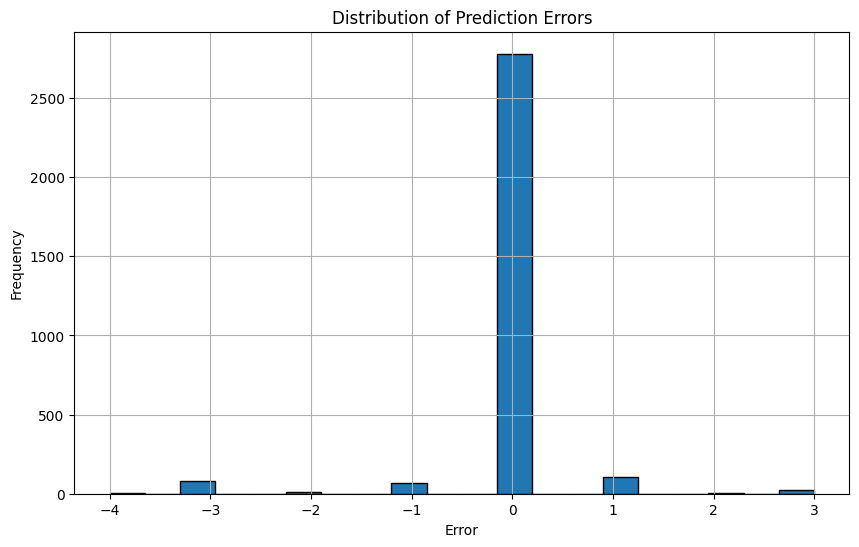

In [17]:
errors = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=20, edgecolor='k')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# Interpretación de la gráfica de distribución de prediction error

La gráfica de distribución de errores de predicción ("prediction error") muestra cómo se distribuyen las diferencias entre los valores reales y las predicciones del modelo para cada muestra del conjunto de prueba.

- **Definición del error de predicción:**
  $$
  \text{Error}_i = y_i - \hat{y}_i
  $$
  donde $y_i$ es el valor real y $\hat{y}_i$ es la predicción del modelo para la muestra $i$.

- **¿Qué representa la gráfica?**
  - El eje $x$ muestra los valores posibles del error (positivos y negativos).
  - El eje $y$ muestra la frecuencia (cuántas veces ocurre cada valor de error).
  - Una distribución centrada en cero indica que el modelo no tiene sesgo sistemático (no tiende a sobrestimar ni subestimar).
  - Si la mayoría de los errores están cerca de cero, el modelo predice bien la mayoría de los casos.
  - Errores muy alejados de cero (colas largas) indican la presencia de outliers o casos donde el modelo falla más.

- **Interpretación práctica:**
  - Una distribución simétrica y centrada en cero es ideal.
  - Si la gráfica está sesgada hacia la derecha (más errores positivos), el modelo tiende a subestimar.
  - Si está sesgada hacia la izquierda (más errores negativos), el modelo tiende a sobrestimar.
  - La dispersión (ancho de la distribución) indica la variabilidad de los errores: una distribución más estrecha es mejor.

- **Ejemplo:**
  Si la mayoría de los errores están entre $-0.5$ y $0.5$, y la media es cercana a cero, el modelo es preciso y no tiene sesgo.

Esta gráfica es una herramienta visual clave para diagnosticar el comportamiento del modelo y detectar posibles problemas de sesgo o varianza excesiva.

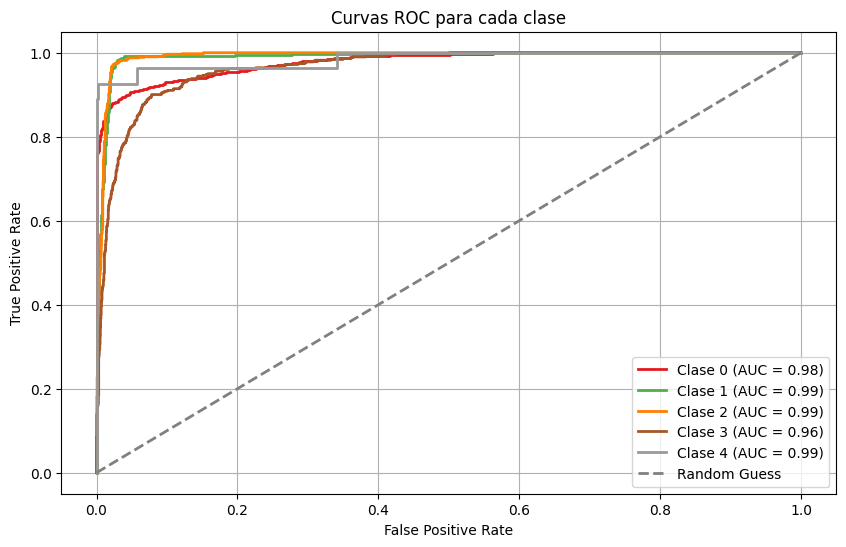

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas para el caso multiclase
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_score = model.predict_proba(X_test)

plt.figure(figsize=(10, 6))
colors = plt.get_cmap('Set1', n_classes)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

# Línea de referencia aleatoria
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC para cada clase')
plt.legend(loc='lower right')
plt.grid()
plt.show()